**Linear Regression**

Linear Regression draws the best straight line through data points, and the best line is the one that minimizes squared errors.

How do you find the best line?

Find the best line that makes predictions closest to actual values.

Why do we measure closest using squared errors?

We use squared errors because we assume the errors(noise) in our data follow a Gaussian (normal) distribution.

When you assume Gaussian noise:

y = Xθ + ε, where ε ~ N(0, σ²)

Then maximizing the likelihood (MLE) is mathematcally identical to minimizing the sum of sqaured error.

In [ ]:
#Implement Linear Reg two ways
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

#Generate data
#Create 200 data points with some random noise
X, y=make_regression(n_samples=200, n_features=1, noise=20, random_state=42)
#train on 80% of data, test on 20% to see if the model generalizes
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

#Method 1: Normal Equation (analytical solution)
# θ = (XᵀX)⁻¹ Xᵀy  ← exact solution, no iteration needed
# add a column of 1s for the intercept term θ₀, without this  your line would always pass through the origin
X_train_b=np.c_[np.ones(len(X_train)), X_train] #add bias
X_test_b=np.c_[np.ones(len(X_test)), X_test]

# - X_train_b.T @ X_train_b → computes X^T X (matrix multiplication)
# - np.linalg.inv(...) → computes (X^T X)^(-1) (matrix inversion)
# - @ X_train_b.T @ y_train → multiplies by X^T y
# - Result: θ = [θ₀, θ₁] (intercept and slope)
theta_normal=np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train
y_pred_normal=X_test_b @ theta_normal # make predictions by multiplying test data by learned parameters

print("Normal Equation")
print(f"θ: {theta_normal.round(4)}")
print(f"Test MSE: {mean_squared_error(y_test, y_pred_normal):.4f}")
print(f"Test R2: {r2_score(y_test, y_pred_normal):.4f}")

Normal Equation
θ: [ 2.4461 86.5115]
Test MSE: 437.5499
Test R2: 0.9450


**Method 1: Normal Equation (The calculator Approach)**

Formula: θ = (X^T X)^(-1) X^T y

What it does: Direcly calculates the exact best parameters in one shot

Analogy: Like using a calculator to solve 2x+3=7, you get x=2 instantly

Pros: No iteration needed, no learning rate to tune, exact answer

Cons: Matrix inversion is O(n³), impossible with millions of features(liek images with 1M pixels)


=== Gradient Descent ===
θ: [ 1.6918 79.0674]
Test MSE:  437.5499
Test R²:   0.9450


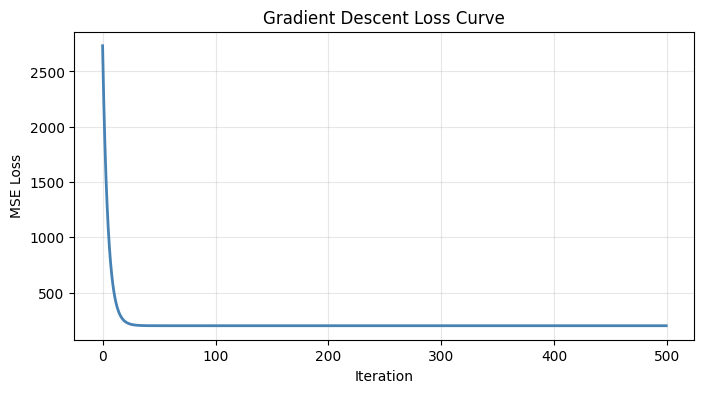

In [ ]:
# Method 2: Gradient Descent
def compute_mse(X, y, theta):
  m=len(y)
  predictions= X @ theta
  return (1/(2*m)) * np.sum((predictions-y)**2)

def gradient_descent(X, y, learning_rate=0.01, n_iterations=1000):
  m, n=X.shape
  theta=np.zeros(n) #start at random parameters
  loss_history=[]

  for i in range(n_iterations):
    predictions=X @ theta #make predictions with current theta if theta=[10, 50] the price = 10+50*size
    errors=predictions-y #predicted - actual
    gradients=(1/m) * X.T @ errors #this is ∂Loss/∂θ #the slope of the loss function, tells us if we increase θ₁ by 1, loss will increase/decrease by this much, the gradient points uphill, so we go the opposite direction
    theta=theta-learning_rate*gradients #update parameters, learning_rate=step size (like how big of a step the hiker takes), too big then overshoot the min(hiker jumps too far, misses the valley), too small, takes forever to converge
    loss_history.append(compute_mse(X, y, theta))

  return theta, loss_history

#scale features first (criticle for gradient descent)
#why scale? imagine geatures with different ranges:
# feature 1 (house size) : 1000-5000 sq ft
# feature 2 (no of bedrooms): 1-5
# problem: The gradient will be hude for feature 1, tiny for feature 2
# the loss landscape becomes long, narrow valley
# gradient descent zigzags wildly instead of going staright down
# standard scaler transforms all features to have mean=0, std=1, GD converges much faster
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

X_train_gd = np.c_[np.ones(len(X_train_scaled)), X_train_scaled]
X_test_gd  = np.c_[np.ones(len(X_test_scaled)),  X_test_scaled]

theta_gd, loss_history=gradient_descent(X_train_gd, y_train, learning_rate=0.1, n_iterations=500)

y_pred_gd=X_test_gd @ theta_gd

print("\n=== Gradient Descent ===")
print(f"θ: {theta_gd.round(4)}")
print(f"Test MSE:  {mean_squared_error(y_test, y_pred_gd):.4f}")
print(f"Test R²:   {r2_score(y_test, y_pred_gd):.4f}")

# Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='steelblue', linewidth=2)
plt.xlabel("Iteration"); plt.ylabel("MSE Loss")
plt.title("Gradient Descent Loss Curve")
plt.grid(alpha=0.3)
plt.show()

**Method 2: Gradient Descent (The Hiker Approach)**

What it does: Starts with random θ, takes small steps downhill on the loss landscape untill reaching the bottom

Analogy: Like a hiker descending a mountain in fog, can't see the whole landscape, just fllows the steepest downward slope.

Pros: Scales to massive datasets (billions of data points, millions of features)

Cons: Needs tuning (lr), takes many iterations approximate.

WHY THE NORMAL EQUATION FAILS AT SCALE:

look at the normal equation again:

θ = (X^T X)^(-1) X^T y

the problem: Matrix inversion is O(n³)

10 features --> 1000 operations
1,000,000 features -->(like a 1000 * 1000 image) --> computationally impossible

This is why DL uses GD

A deep neural network has millions or billions of parameters. You can't invert a billion * billion matrix.

Gradient descent only needs to:

* Compute the gradient O(n) per iteration
* Update parameters O(n) per iteration


"Normal Equation gives the exact answer but dies at scale (O(n³)). Gradient Descent trades exactness for scalability — that's why it powers modern AI"

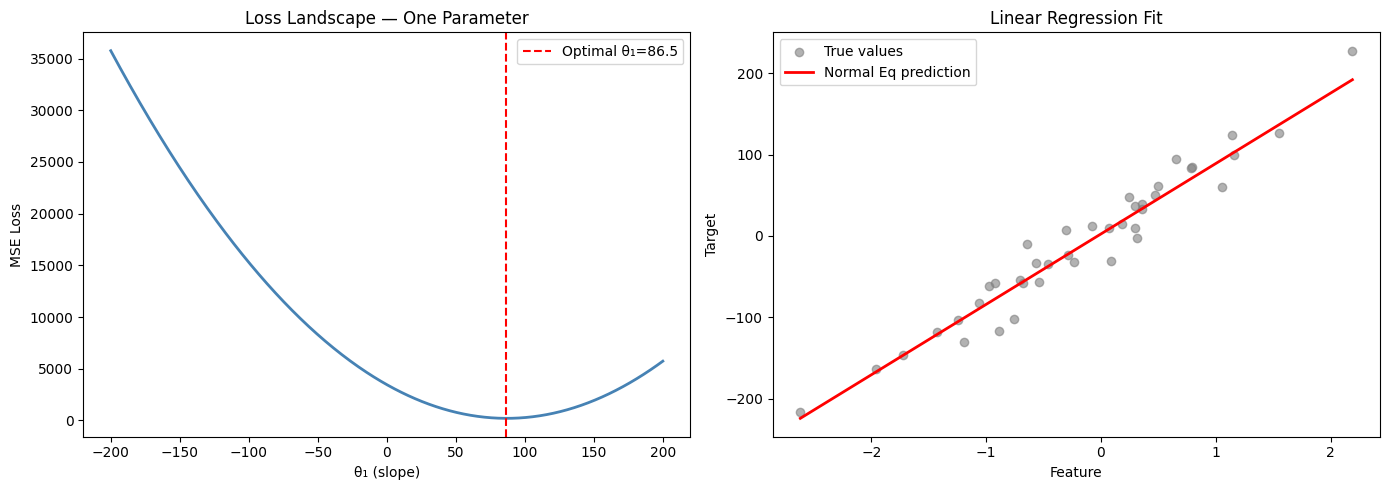

In [ ]:
# Show gradient descent converging from different starting points
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Loss landscape (1D)
thetas = np.linspace(-200, 200, 400)
X_b_all = np.c_[np.ones(len(X)), X]
losses = [compute_mse(X_b_all, y,
          np.array([0, t])) for t in thetas]

axes[0].plot(thetas, losses, color='steelblue', linewidth=2)
axes[0].axvline(theta_normal[1], color='red', linestyle='--',
                label=f'Optimal θ₁={theta_normal[1]:.1f}')
axes[0].set_xlabel("θ₁ (slope)"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Loss Landscape — One Parameter")
axes[0].legend()

# Right: Predictions vs actual
axes[1].scatter(X_test, y_test, alpha=0.6, color='gray', label='True values')
x_line = np.linspace(X_test.min(), X_test.max(), 100)
axes[1].plot(x_line,
             theta_normal[0] + theta_normal[1]*x_line,
             'r-', linewidth=2, label='Normal Eq prediction')
axes[1].set_xlabel("Feature"); axes[1].set_ylabel("Target")
axes[1].set_title("Linear Regression Fit")
axes[1].legend()

plt.tight_layout()
plt.show()

What this shows: A u-shaped curve (parabola) representing the loss for diff values of θ₁

the red line:The optimal value found by the normal equation (the bottom of U)

Gradient descent: would start somewhere on the curve and slide down to the red line

the Loss curve visualization:

* Far left/right: High loss(bad predictions)
* Center (red line): Minimum loss (best predictions)
* Gradient decent follows the slope down to the center

**Imagine you're a real estate agent trying to price houses:**

**Chapter 1: The Data**

You have 200 past sales: size and price. There's noise (renovations, location) but generally: bigger house = higher price.

**Chapter 2: The Line**

You want to draw a line: price = θ₀ + θ₁ × size. But which line is BEST?

**Chapter 3: The Loss Function**

You decide "best" means minimizing squared errors. Why squared? Because you assume the noise in your data is Gaussian, and that assumption mathematically leads to MSE via maximum likelihood!

**Chapter 4: The Calculator (Normal Equation)**

You could use a formula to compute the exact best line in one shot. But if you had 1 million features (like pixel values in images), the calculator would explode!

**Chapter 5: The Hiker (Gradient Descent)**

Instead, you start with a random line and iteratively improve it by following the gradient downhill. It takes longer, but it SCALES to massive data!

**Chapter 6: Feature Scaling**

You scale your features (size, bedrooms, etc.) to the same range so gradient descent doesn't zigzag like crazy.

**Chapter 7: The Result**

After 500 steps, gradient descent finds almost the same line as the Normal Equation, but it could handle 1 billion features if needed!

***"This is why modern AI uses gradient descent — not because it's better, but because it's the ONLY method that scales!"***

**Logistic Regression**

we learned to predict numbers(house prices). Now we will predict probabilities(is this email spam?)

The problem: Linear regression outputs any number from -∞ to +∞. But probabilities must be between 0 and 1.

The solution: Squeeze the output through a probability squisher called the sigmoid function.

The Sigmoid Function S-shaped:

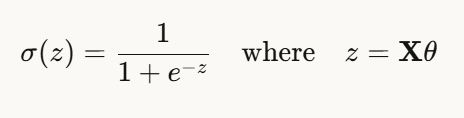

What does this actually do?

Input(z): Any number from -∞ to +∞(like linear reg output)

Output(σ(z)): A number squeezed between 0 and 1 (a probability)

**Key Properties to Remember:**

- **σ(0) = 0.5:** When z = 0, you get exactly 50% probability
- **σ(large positive) ≈ 1:** When z = 10, you get ≈ 99.9% probability
- **σ(large negative) ≈ 0:** When z = -10, you get ≈ 0.01% probability
- **Always outputs between 0 and 1:** Perfect for probabilities!

Where does Binary Cross-Entropy Loss Come From?

It is not invented it is drive from MLE:

the derivation:

Step 1: We model the probability of class 1 as p(y=1|x) = σ(Xθ)

Step 2: We want to maximize the likelihood of seeing our actual data.

Step 3: Taking the log (to make math easier) and flipping to minimize (instead of maximize) gives us:

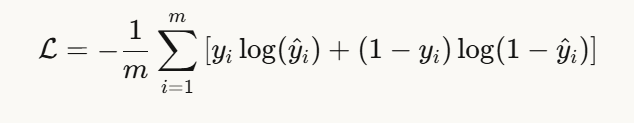

This is Binary Cross-entropy Loss

What does this function actually measure?

When y=1 (actual class is 1) : Loss=-log(ŷ)
* - If ŷ = 0.9 (we predicted high probability) → loss is small
* - If ŷ = 0.1 (we predicted low probability) → loss is HUGE

When y=0(actual class is 0): Loss=-log(1-ŷ)
* - If ŷ = 0.1 (we predicted low probability) → loss is small
* - If ŷ = 0.9 (we predicted high probability) → loss is HUGE


In [ ]:
#Logistic Regression from scratch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve)

#Data
X, y=make_classification(n_samples=1000, n_features=2, n_redundant=0, n_informative=2, random_state=42, n_clusters_per_class=1)
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

scaler=StandardScaler()
X_train_s=scaler.fit_transform(X_train)
X_test_s=scaler.transform(X_test)

#from scratch Logistic regression
class LogisticRegressionScratch:
  def __init__(self, learning_rate=0.1, n_iterations=1000):
    self.lr=learning_rate
    self.n_iter=n_iterations
    self.theta=None
    self.loss_history=[]

  def sigmoid(self, z):
    #Numerically stable sigmoid
    return np.where(z>=0, 1/(1+np.exp(-z)), np.exp(z)/(1+np.exp(z))) #why two versions? numerical stability
    # for large positive z: 1/1+e^(-z) works great
    # for large negative z: e^z/1+e^z avoids overflow
    #np.where if z>=0 use first formula, ow use second

  def compute_loss(self, y, y_hat):
    m=len(y)# get no of examples m
    #clip to avoid log(0) = -∞
    y_hat=np.clip(y_hat, 1e-10, 1-1e-10) #clip to [1e-10, 1-1e-10] because If ŷ = 0, then log(ŷ) = log(0) = -∞ → code crashes
    # If ŷ = 1, then log(1-ŷ) = log(0) = -∞ → code crashes!
    #cliping ensures ŷ is never exactly 0 and 1, preventing matematical errors while keeping predictions extremely close to 0 or 1
    return -(1/m) * np.sum(y*np.log(y_hat)+(1-y) * np.log(1-y_hat)) #binary cross entropy formula

  def fit(self, X, y):
    m,n=X.shape #get number of examples(m) and features(n)
    X_b = np.c_[np.ones(m), X] #add bias
    self.theta=np.zeros(n+1) #initialize theta to zeros (starting guess)

    for _ in range(self.n_iter): #loop for specified no of iterations
      z=X_b @ self.theta #compute  z = Xθ (the linear combination)
      y_hat=self.sigmoid(z) #Apply sigmoid to get predictions ŷ = σ(Xθ) between 0 and 1
      errors=y_hat-y
      gradients=(1/m)*X_b.T @ errors #calculate gradient using the formula: ∇J(θ) = (1/m) X^T (ŷ - y) which directs to move θ
      self.loss_history.append(self.compute_loss(y, y_hat))


  def predict_prob(self, X):
    X_b=np.c_[np.ones(len(X)), X]
    return self.sigmoid(X_b @ self.theta)

  def predict(self, X, threshold=0.5):
    return (self.predict_prob(X) >= threshold).astype(int)
    #Why 0.5?
    #When z = 0, sigmoid outputs exactly 0.5 — this is the "decision boundary"!
    #If Xθ > 0 (positive side) → predict class 1
    #If Xθ < 0 (negative side) → predict class 0

#train

model=LogisticRegressionScratch(learning_rate=0.1, n_iterations=1000)
model.fit(X_train_s, y_train)
y_pred=model.predict(X_test_s)
y_prob=model.predict_prob(X_test_s)

print("=== From-Scratch Logistic Regression ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred))












=== From-Scratch Logistic Regression ===
Accuracy:  0.4800
ROC-AUC:   0.5000

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       104
           1       0.48      1.00      0.65        96

    accuracy                           0.48       200
   macro avg       0.24      0.50      0.32       200
weighted avg       0.23      0.48      0.31       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Threshold**

The default threshold is 0.5, but this is almost never the right choice in real-world problems.

Real-Worl example:
* Missing a fraud (false negative): costs $10,000 in losses

* Flagging a legitimate transaction(false positive): costs $5 in customer service

Solution: Shift your threshold lower (e.g:0.3) to catch more fraud, even if it means more false alarms.

the cost-benefit analysis tells you the threshold should not be 0.5.

WHY THRESHOLD MATTERS?

* Threshold=0.5: Treats both classes equally (assumes equal cost of errors)
* Lower threshold(0.3) more aggressive, predits class 1 more often (higher recall, lower precision)
* Higher threshold(0.7): More conservative, only predicts class 1 when very confident (lower recall, higher precision)

Choose threshold according to your problem!






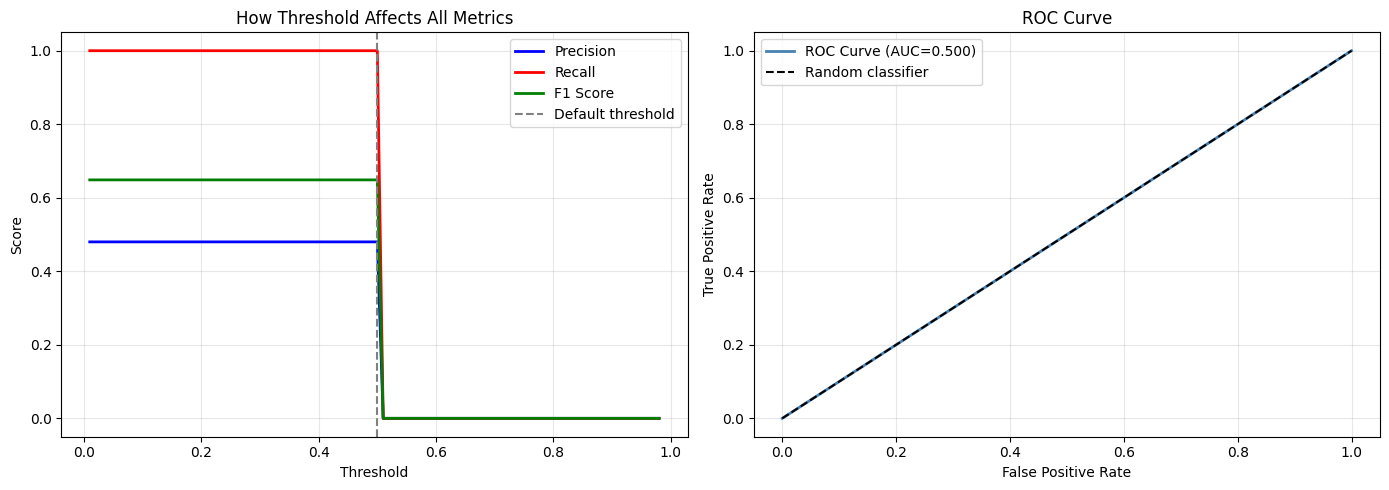

Best threshold for F1: 0.01
Best F1 score: 0.6486

Key insight: In real projects, ALWAYS tune the threshold.
It costs nothing and often gives bigger gains than changing the model.


In [ ]:
#Visualizing threshold effects:
thresholds = np.arange(0.01, 0.99, 0.01) #create 98 diff threshold values from 0.01 to 0.99
precisions, recalls, f1_scores = [], [], [] #will test all to see how it will affects metrics

for thresh in thresholds:
    y_pred_t = (y_prob >= thresh).astype(int) #convert prob to binary predictions using current threshold
    from sklearn.metrics import precision_score, recall_score, f1_score
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        #calculate precision, recall, and F1 score for this threshold, store all values in lists for plotting
        precisions.append(precision_score(y_test, y_pred_t))
        recalls.append(recall_score(y_test, y_pred_t))
        f1_scores.append(f1_score(y_test, y_pred_t))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall vs threshold
axes[0].plot(thresholds, precisions, label='Precision', color='blue', linewidth=2) #as threshold increases, precision goes up
axes[0].plot(thresholds, recalls,    label='Recall',    color='red',  linewidth=2)#as threshold increases, recall goes down(we miss more positives)
axes[0].plot(thresholds, f1_scores,  label='F1 Score',  color='green',linewidth=2)#the balance between precision and recall
axes[0].axvline(0.5, color='gray', linestyle='--', label='Default threshold') #shows where the default 0.5 threshold sits
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Score")
axes[0].set_title("How Threshold Affects All Metrics")
axes[0].legend(); axes[0].grid(alpha=0.3)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'ROC Curve (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', label='Random classifier')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_thresh = thresholds[np.argmax(f1_scores)] # np.argmax(f1_scores) find the index of the max F1-score
#threshold[..] Gets the threshold value at that index, tell us the optimal threshold for maximizing F1
print(f"Best threshold for F1: {best_thresh:.2f}")
print(f"Best F1 score: {max(f1_scores):.4f}")
print()
print("Key insight: In real projects, ALWAYS tune the threshold.")
print("It costs nothing and often gives bigger gains than changing the model.")

**The Trade-off:**

- **Lower threshold:** High recall (catch more positives) but low precision (more false alarms)
- **Higher threshold:** High precision (fewer false alarms) but low recall (miss more positives)

The F1 curve shows you the sweet spot where both are balanced!

**Understanding ROC (Reciever Operating Characteristic)**

* X-axis(FPR): False positive rate=fp/(fp+tn), how many negatives we wrongly classify as positive.
* y-axis(TPR): True positive rate=tp/(tp+fn), same as Recall, How many positives we correctly catch
* The curve: Shows TPR vs FPR at everypossible threshold
* Diagnoal Line: A random classifier (coin flip), if your curve is below this, your model is worse than random.

**What is AUC(Area Under Curve)**
* AUC=1.0: perfect classifier(all positive ranked higher than all negatives)
* AUC=0.5: random classifier(no better than flipping a coin)
* AUC < 0.5 : worse than random(your model is backwards)
* AUC = 0.7-0.8: decent Model
* AUC = 0.8-0.9: Good Model
* AUC > 0.9: Excellent Model

The ROC curve is threshold-independent, it shows model perfromance across ALL thresholds.

This is why AUC is so popular: It's a singal number that summarizes model quality without committing to a specific threshold.

**regularization**

It punishes model for being too confident/complex, forcing it to learn simple, generalizable patterns instead of memorizing noise.

L2 regularization (Ridge):

* formula: Add λ × (sum of squared weights) to the loss
* effect: squaring means larger weights get punished more (quadratically)
* Result: All weights shrink, but none go exactly to zero

L2 regularization add the summ of squared weights to the loss function. this penalizes large weights quadratically, causing all weights to shrink toward zero but never exactly zero. It is like telling the model: use all features but dont trust any single one too much.

when to use L2:
* when you think most/all features are relevant
* whenyou want smooth, stable predictions
* default choice for most problems

L1 Regularization (Lasso):

* formula: Add λ × (sum of absolute values of weights) to the loss
* Effect: penalty is linear (same cost per unit of weight, regardless of size)
* result: Forces some weights to exactly zero, automatic feature selction.

L1 regularization add sum of absolute values of weight to the loss. This creates a constant penalty regardless of weight size, which forces unimportant weights to exactly zero. It performs automatic feature selection, essentially telling the model: Only keep the features that really matter.

When to use L1:
* Wheh have many features but suspect only a few are important
* When you want automatic feature selection
* When you need an interpretable model(fewer non-zero weights)



In [ ]:
class LogisticRegressionRegularised:
    def __init__(self, learning_rate=0.1, n_iterations=1000,
                 penalty='l2', C=1.0):
        """
        C = inverse of regularisation strength (like sklearn)
        High C = less regularisation (trust the data more)
        Low C  = more regularisation (trust the prior more)
        """
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.penalty = penalty
        self.C = C
        self.theta = None
        self.loss_history = []

    def sigmoid(self, z):
        return np.where(z >= 0,
                        1/(1+np.exp(-z)),
                        np.exp(z)/(1+np.exp(z)))

    def fit(self, X, y):
        m, n = X.shape
        X_b = np.c_[np.ones(m), X]
        self.theta = np.zeros(n + 1)
        lam = 1.0 / self.C  # convert C to lambda

        for _ in range(self.n_iter):
            z = X_b @ self.theta
            y_hat = self.sigmoid(z)
            errors = y_hat - y
            gradients = (1/m) * X_b.T @ errors

            # Add regularisation gradient (don't regularise bias term!)
            if self.penalty == 'l2':
                reg_grad = (lam/m) * self.theta
                reg_grad[0] = 0  # don't regularise bias
            elif self.penalty == 'l1':
                reg_grad = (lam/m) * np.sign(self.theta)
                reg_grad[0] = 0

            self.theta -= self.lr * (gradients + reg_grad)
            y_hat_clip = np.clip(y_hat, 1e-10, 1-1e-10)
            self.loss_history.append(
                -(1/m)*np.sum(y*np.log(y_hat_clip) +
                              (1-y)*np.log(1-y_hat_clip)))

    def predict_proba(self, X):
        X_b = np.c_[np.ones(len(X)), X]
        return self.sigmoid(X_b @ self.theta)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# Compare regularisation strengths
results = []
for C in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]: #loop through different C values testing from very strong to very weak regularization
    m = LogisticRegressionRegularised(C=C) #train the model,each C value creates a different model
    m.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, m.predict(X_test_s)) #How ell does it generalize to new data?
    weights_magnitude = np.abs(m.theta[1:]).mean()#measure weight magnitude, computes avg absolute weight(excluding bias)
    results.append({'C': C, 'Accuracy': acc,
                    'Avg |weight|': weights_magnitude})

import pandas as pd
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))
print()
print("Notice: as C decreases (more regularisation),")
print("weights shrink but accuracy may not — regularisation prevents overfitting.")

      C  Accuracy  Avg |weight|
  0.001     0.895      0.132621
  0.010     0.895      0.621674
  0.100     0.895      1.468329
  1.000     0.895      1.995045
 10.000     0.900      2.079720
100.000     0.900      2.088671

Notice: as C decreases (more regularisation),
weights shrink but accuracy may not — regularisation prevents overfitting.


**Understanding C**

C is the inverse of regularization strength(lambda)

C=confidence in your data
* High C= i trust my data is clean and reprsentatiove, less regularization
* Low C=My data might be noisy or limited, more regularization

Why skip the bias term?
* The bias control teh intercept, it shifts the decision boundary up/down
* It does not depend on any feature, so it can't cause overfitting
* regularizing it would hurt the performance, your model might not fit the average correctly.

The bias is like the baseline temperature. Regularization says, dont trust temperature sensors too much, but it should not prevent you from knowing it is generally 70f outside.

**The Key Pattern:**

As C decreases (more regularization):

- Weights shrink (model becomes simpler)
- Train accuracy drops (doesn't fit training data perfectly)
- Test accuracy often IMPROVES (generalizes better!)

**Until** you regularize too much and start underfitting (both train and test accuracy drop)

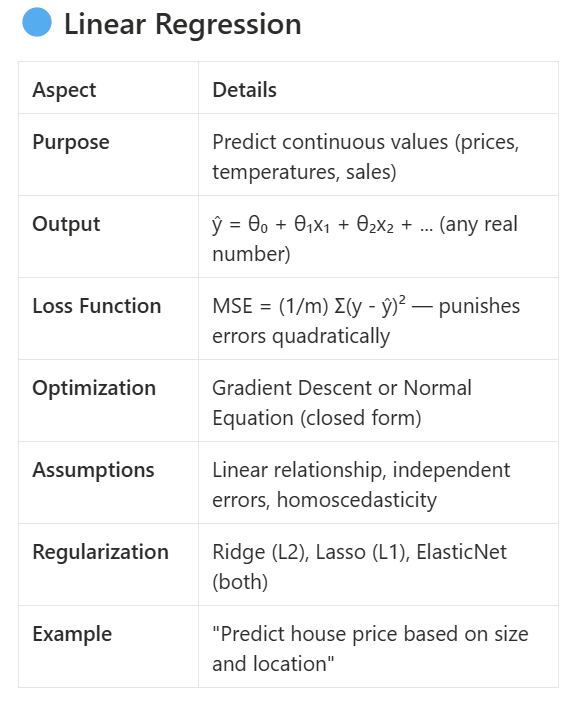


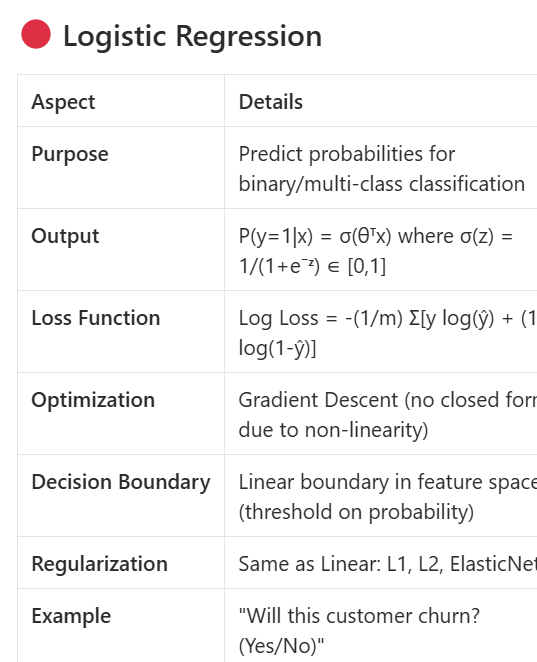

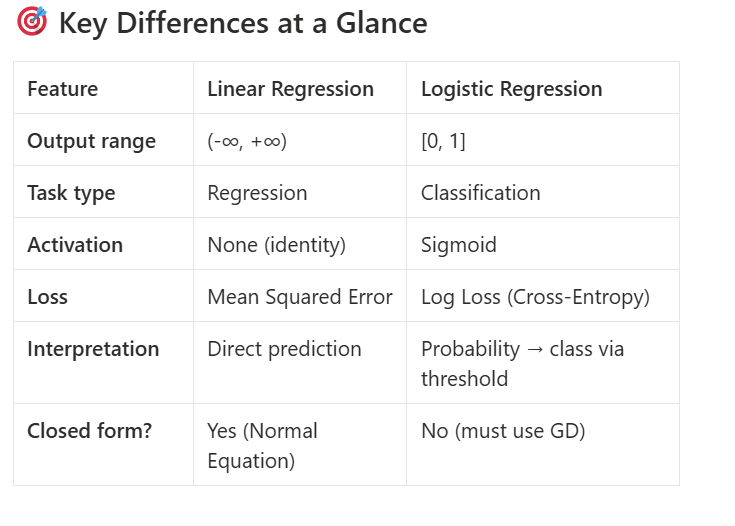

**Linear Regression:** Fits a line/plane through points. "What's the expected value?"

**Logistic Regression:** Fits an S-curve through binary outcomes. "What's the probability of yes?"

**Both use:** Linear combinations of features (θᵀx)

**Difference:** Logistic squashes this through sigmoid to get probabilities

Regularization prevents overfitting by adding a penalty term to the loss function that discourages large weights.L2 regularization adds λ times the sum of squared weights. This shrinks all weights toward zero but never exactly to zero, creating a smooth, stable model.L1 regularization adds λ times the sum of absolute weights. This forces unimportant weights to exactly zero, performing automatic feature selection.The regularization strength is controlled by λ (or C = 1/λ). We choose it via cross-validation, balancing model complexity with generalization performance.Crucially, we don't regularize the bias term because it only shifts the prediction level and can't cause overfitting

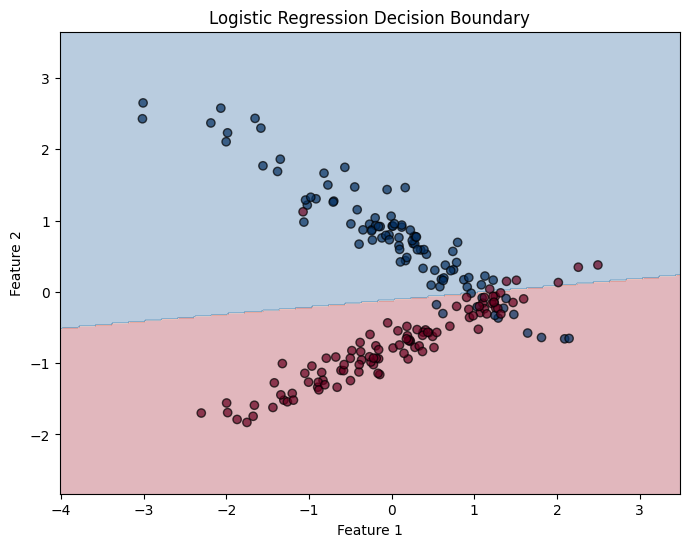

In [ ]:
# Visualise decision boundary of your trained model
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[:,0], X[:,1], c=y, cmap='RdBu',
                edgecolors='k', alpha=0.7)
    plt.title(title)
    plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
    plt.show()

best_model = LogisticRegressionRegularised(C=1.0)
best_model.fit(X_train_s, y_train)
plot_decision_boundary(best_model, X_test_s, y_test,
                       "Logistic Regression Decision Boundary")

The decision boundary is the geometric surface where the model's predicted probability equals the classification threshold (typically 0.5).In logistic regression, this occurs when θᵀx = 0, which defines a linear boundary—a line in 2D, a plane in 3D, or a hyperplane in higher dimensions.Points on one side of this boundary are classified as one class (probability > 0.5), and points on the other side as the other class (probability < 0.5).The position and orientation of this boundary are determined by the learned weights θ. The farther a point is from the boundary, the more confident the model is about its prediction.A key limitation is that logistic regression can only create linear decision boundaries. For non-linearly separable data, we need to either engineer non-linear features or use more complex models